# The Pink Tax in Indian Online Retail — Data Analysis Notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mppyxx/PinkTax/blob/main/notebooks/PinkTax_Analysis.ipynb)

**Question:** do products marketed to women cost more than comparable products marketed to men?

**Data:** three public Kaggle datasets with prices in Indian Rupees (₹): Myntra (fashion),
BigBasket (beauty & hygiene) and Amazon.in (personal care).

**Libraries used:** NumPy · Pandas · Matplotlib · Seaborn · Plotly · SciPy · Statsmodels ·
Scikit-learn · OpenPyXL

| Step | What happens |
|---|---|
| 1 | Setup and data download |
| 2 | First look at the raw data |
| 3 | Cleaning, gender tagging and category tagging |
| 4 | Exploratory data analysis (EDA) |
| 5 | Hypothesis testing |
| 6 | Brand-matched comparison |
| 7 | Regression with fixed effects |
| 8 | Machine-learning check |
| 9 | Interactive chart, Excel and Power BI export |

## 1. Setup
In Google Colab the first cell clones the project repository; locally it just uses the repo folder.

In [1]:
import sys, os
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !git clone -q https://github.com/mppyxx/PinkTax.git
    %cd PinkTax/notebooks
    !pip -q install -r ../requirements.txt
sys.path.insert(0, os.path.abspath("../src"))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from IPython.display import Image, display

from config import RAW, PROCESSED, TABLES, FIGURES, GENDER_COLORS, set_style
set_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 3.0.6 | numpy 2.4.6 | seaborn 0.13.2


### Download the Kaggle datasets
The script saves the three CSV files into `data/raw/` (skips files already present).

In [3]:
%run ../src/01_download_data.py

[skip] myntra_products.csv already present
[skip] bigbasket_products.csv already present
[skip] amazon_in_products_2023.csv already present


## 2. First look at the raw data

In [4]:
myntra = pd.read_csv(RAW / "myntra_products.csv")
bigbasket = pd.read_csv(RAW / "bigbasket_products.csv")
print("Myntra   :", myntra.shape)
print("BigBasket:", bigbasket.shape)
myntra.head(3)

Myntra   : (168029, 13)
BigBasket: (27555, 10)


,product_name,brand_name,rating,rating_count,marked_price,discounted_price,sizes,product_link,img_link,product_tag,brand_tag,discount_amount,discount_percent
0,Croc Textured Two Fold Wallet,Lino Perros,0.0,0,1295,828,Onesize,wallets/lino-perros/lino-perros-women-peach-co...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",wallets,lino-perros,467,36
1,Men Striped Sliders,Mast & Harbour,4.0,76,1299,584,"UK6,UK7,UK8,UK9,UK10,UK11",flip-flops/mast--harbour/mast--harbour-men-nav...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",flip-flops,mast--harbour,715,55
2,Printed A-line Kurta,Biba,4.3,66,1999,1599,"S,M,L,XL,XXL,3XL",kurtas/biba/biba-women-off-white--black-printe...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",kurtas,biba,400,20


In [5]:
myntra.info()

<class 'pandas.DataFrame'>
RangeIndex: 168029 entries, 0 to 168028
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   product_name      168029 non-null  str    
 1   brand_name        168029 non-null  str    
 2   rating            168029 non-null  float64
 3   rating_count      168029 non-null  int64  
 4   marked_price      168029 non-null  int64  
 5   discounted_price  168029 non-null  int64  
 6   sizes             168029 non-null  str    
 7   product_link      168029 non-null  str    
 8   img_link          168029 non-null  str    
 9   product_tag       168029 non-null  str    
 10  brand_tag         168029 non-null  str    
 11  discount_amount   168029 non-null  int64  
 12  discount_percent  168029 non-null  int64  
dtypes: float64(1), int64(5), str(7)
memory usage: 16.7 MB


In [6]:
# The gender is hidden inside Myntra's product URL, e.g. ".../puma-men-black-sneakers/..."
myntra["gender_raw"] = myntra["product_link"].str.extract(r"-(men|women|boys|girls|unisex)-")[0]
myntra["gender_raw"].value_counts(dropna=False)

gender_raw
women     58436
men       53615
NaN       43823
girls      4671
boys       4209
unisex     3275
Name: count, dtype: int64

In [7]:
bigbasket[bigbasket.category == "Beauty & Hygiene"].type.value_counts().head(12)

type
Face Care                 1508
Ayurveda                   538
Men's Deodorants           500
Shampoo & Conditioner      461
Bathing Bars & Soaps       390
Body Care                  340
Aromatherapy               276
Supplements & Proteins     240
Hand Wash & Sanitizers     233
Hair Oil & Serum           217
Eau De Toilette            211
Face & Body                198
Name: count, dtype: int64

## 3. Cleaning and tagging
`src/02_clean_and_tag.py` does the heavy lifting:

* keeps only product types that exist in **both** a men's and a women's version,
* tags gender from Myntra URLs and from English + Hindi keywords (`men`, `women`, `पुरुष`, `महिला` …),
* tags the product category with ordered regular-expression rules,
* extracts pack size (ml / g) so that liquids can be compared per 100 ml,
* removes zero prices, duplicates and extreme outliers (3 × IQR on the log scale).

In [8]:
%run ../src/02_clean_and_tag.py

   source                                                  step  rows
   Myntra                                     raw rows in scope 72914
BigBasket                                     raw rows in scope  7273
Amazon.in                                     raw rows in scope 62078
      all                       after gender + category tagging 80008
      all                  after removing zero / missing prices 79817
      all after keeping comparable categories (>=15 per gender) 79553
      all                         after log-IQR outlier removal 79391

Master table: 79,390 products
gender       Men  Women
source                 
Amazon.in   3785   2098
BigBasket    469    267
Myntra     44451  28320
gender                                   Men  Women
source    age_group category                       
Amazon.in Adult     Body Wash             97     28
                    Deodorant            766    377
                    Face Wash             95     31
                    Hair Remo

In [9]:
df = pd.read_csv(PROCESSED / "pinktax_master.csv", low_memory=False)
df["female"] = (df.gender == "Women").astype(int)
df.sample(5, random_state=7)

,source,product_id,product_name,brand,segment,category,gender,age_group,mrp,selling_price,discount_pct,size_value,size_unit,unit_price_100,rating,rating_count,female
5024,Amazon.in,B0C6JCB25Y,हस्तनिर्मित नीली महिला इत्र,NaN,Personal Care,Perfume,Women,Adult,300.0,200.00,33.333333,NaN,NaN,NaN,NaN,0.0,1
6615,BigBasket,26834,Eau de Perfume - Sensual Jasmine For Women,BIOTIQUE,Personal Care,Perfume,Women,Adult,699.0,524.25,25.000000,NaN,NaN,NaN,3.7,NaN,1
35994,Myntra,18450952,Casual Shirt,U.S. POLO ASSN.,Apparel,Shirts,Men,Adult,2499.0,2499.00,0.000000,NaN,NaN,NaN,NaN,0.0,0
39237,Myntra,18254266,Striped Casual Shirt,CAVALLO BY LINEN CLUB,Apparel,Shirts,Men,Adult,1599.0,1199.00,25.015635,NaN,NaN,NaN,NaN,0.0,0
68999,Myntra,17240154,Women Flared Pleated High-Rise Trousers,SASSAFRAS,Apparel,Trousers,Women,Adult,1799.0,629.00,65.036131,NaN,NaN,NaN,NaN,0.0,1


In [10]:
pd.read_csv(PROCESSED / 'cleaning_log.csv')

,source,step,rows
0,Myntra,raw rows in scope,72914
1,BigBasket,raw rows in scope,7273
2,Amazon.in,raw rows in scope,62078
3,all,after gender + category tagging,80008
4,all,after removing zero / missing prices,79817
5,all,after keeping comparable categories (>=15 per ...,79553
6,all,after log-IQR outlier removal,79391


## 4. Exploratory data analysis

In [11]:
df.pivot_table(index=["source", "segment"], columns="gender", values="mrp",
               aggfunc=["count", "median"]).round(0)

count         median        
gender                     Men  Women     Men   Women
source    segment                                    
Amazon.in Personal Care   3785   2098   774.0   699.0
BigBasket Personal Care    469    267   348.0   500.0
Myntra    Accessories     2290   2377  2699.0  2799.0
          Apparel        35424  22853  1899.0  1790.0
          Footwear        6410   2912  2597.0  1899.0
          Personal Care    327    178  1499.0  1798.0

In [12]:
df.groupby(["segment", "gender"])[["mrp", "selling_price", "discount_pct"]].describe().T.round(1).head(24)

segment             Accessories           Apparel          Footwear          Personal Care         
gender                      Men    Women      Men    Women      Men    Women           Men    Women
mrp           count      2290.0   2377.0  35424.0  22853.0   6410.0   2912.0        4581.0   2543.0
              mean       5545.4   4685.9   2105.1   1951.7   2980.5   2540.8        1202.4   1454.1
              std        7228.1   4702.5   1401.3   1199.3   2071.8   2263.5        1506.3   2194.2
              min         499.0    249.0    129.0    149.0    199.0    289.0          42.0     60.0
              25%        1799.0   1599.0   1299.0   1199.0   1499.0    999.0         399.0    399.0
              50%        2699.0   2799.0   1899.0   1790.0   2597.0   1899.0         749.0    699.0
              75%        6283.8   6045.0   2499.0   2399.0   3995.0   2999.0        1283.0   1305.0
              max       63950.0  43500.0  32995.0  29995.0  18999.0  19999.0       14999.0  22000.0
selling_price count      2290.0   2377.0  35424.0  22853.0   6410.0   2912.0        4581.0   2543.0
              mean       4063.3   3206.6   1376.3   1146.2   1700.5   1743.7        1082.6   1330.7
              std        5630.1   4176.7   1079.4    920.1   1625.1   2117.2        1512.7   2206.2
              min         249.0    249.0    129.0    137.0    199.0    239.0          42.0     25.0
              25%         922.0    749.0    699.0    623.0    799.0    619.0         295.0    290.0
              50%        1703.5   1349.0   1079.0    887.0   1199.0    919.0         534.0    489.0
              75%        4745.0   3725.0   1749.0   1349.0   1978.8   1829.0        1247.0   1248.0
              max       45900.0  43500.0  25000.0  22990.0  18999.0  19999.0       14999.0  22000.0
discount_pct  count      2290.0   2377.0  35424.0  22853.0   6410.0   2912.0        4581.0   2543.0
              mean         31.6     37.7     34.1     39.0     38.1     34.6          16.7     17.1
              std          24.9     25.5     22.3     24.8     27.3     25.3          19.6     20.3
              min           0.0      0.0      0.0      0.0      0.0      0.0           0.0      0.0
              25%          10.0     15.0     15.0     19.1     13.0     10.0           0.0      0.0
              50%          30.0     40.0     38.0     50.0     40.0     40.0           8.0      9.1
              75%          50.0     60.0     50.1     60.0     60.0     56.0          30.7     30.1
              max          89.7     86.9     88.1     87.0     90.0     83.0          90.1     84.0

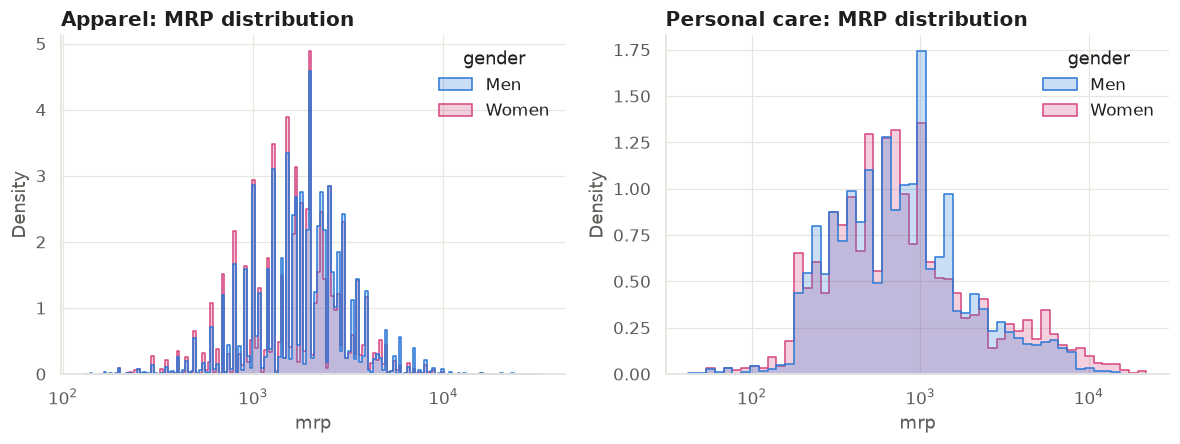

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df[df.segment == "Apparel"], x="mrp", hue="gender", palette=GENDER_COLORS,
             log_scale=True, element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Apparel: MRP distribution")
sns.histplot(data=df[df.segment == "Personal Care"], x="mrp", hue="gender", palette=GENDER_COLORS,
             log_scale=True, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Personal care: MRP distribution")
plt.show()

Prices are strongly right-skewed, so medians, log prices and non-parametric tests are used throughout.

The statistics are computed here (quietly) so that every chart can be drawn; they are discussed in Section 5.

In [14]:
%%capture
%run ../src/03_analysis.py
%run ../src/04_visualise.py

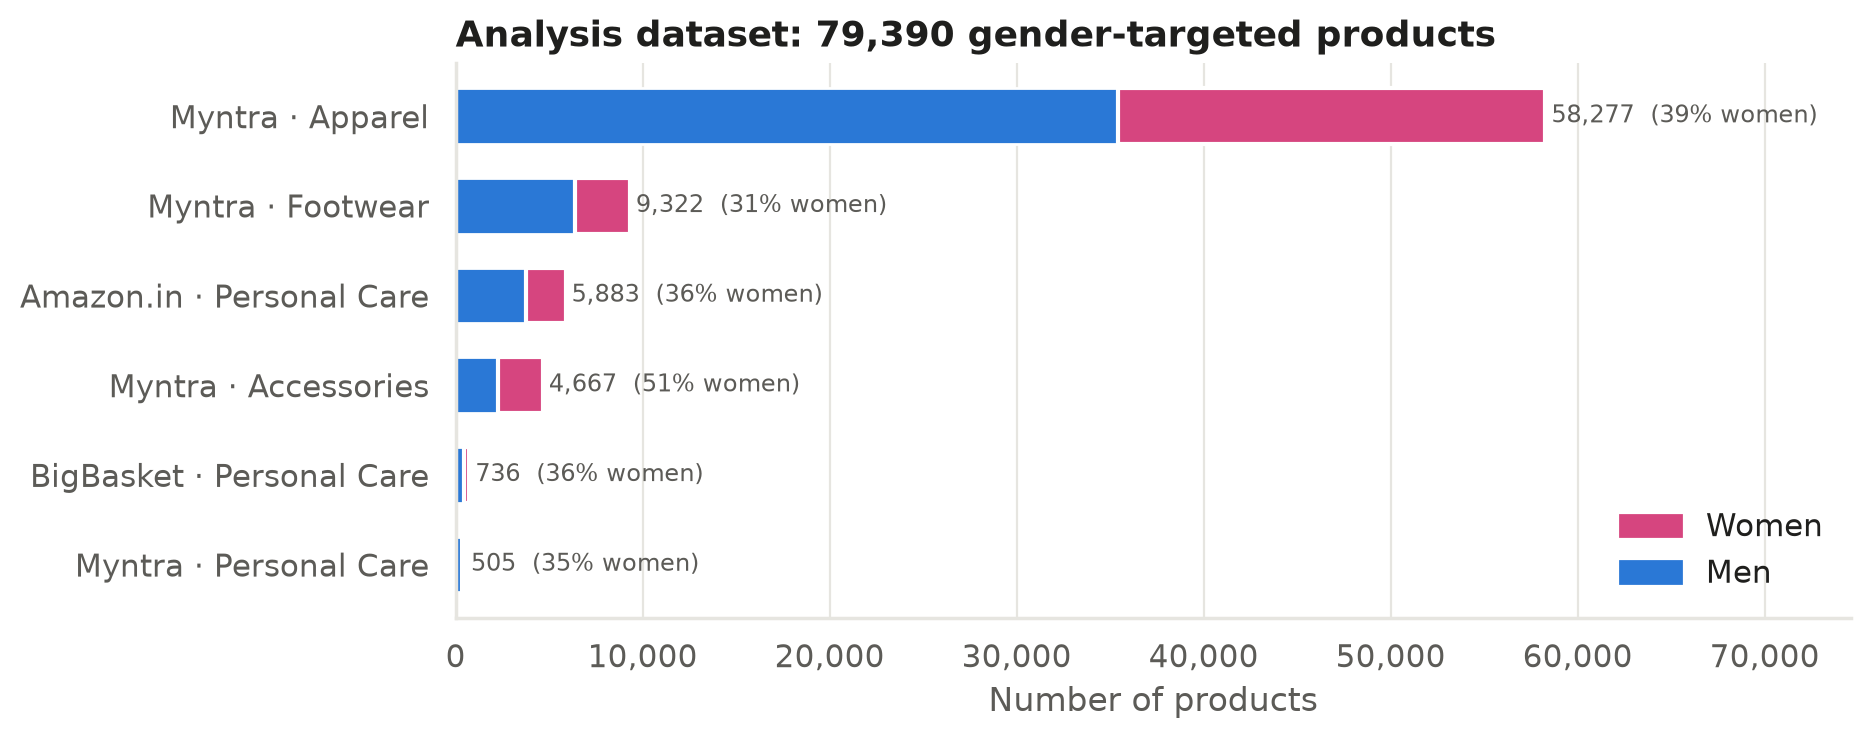

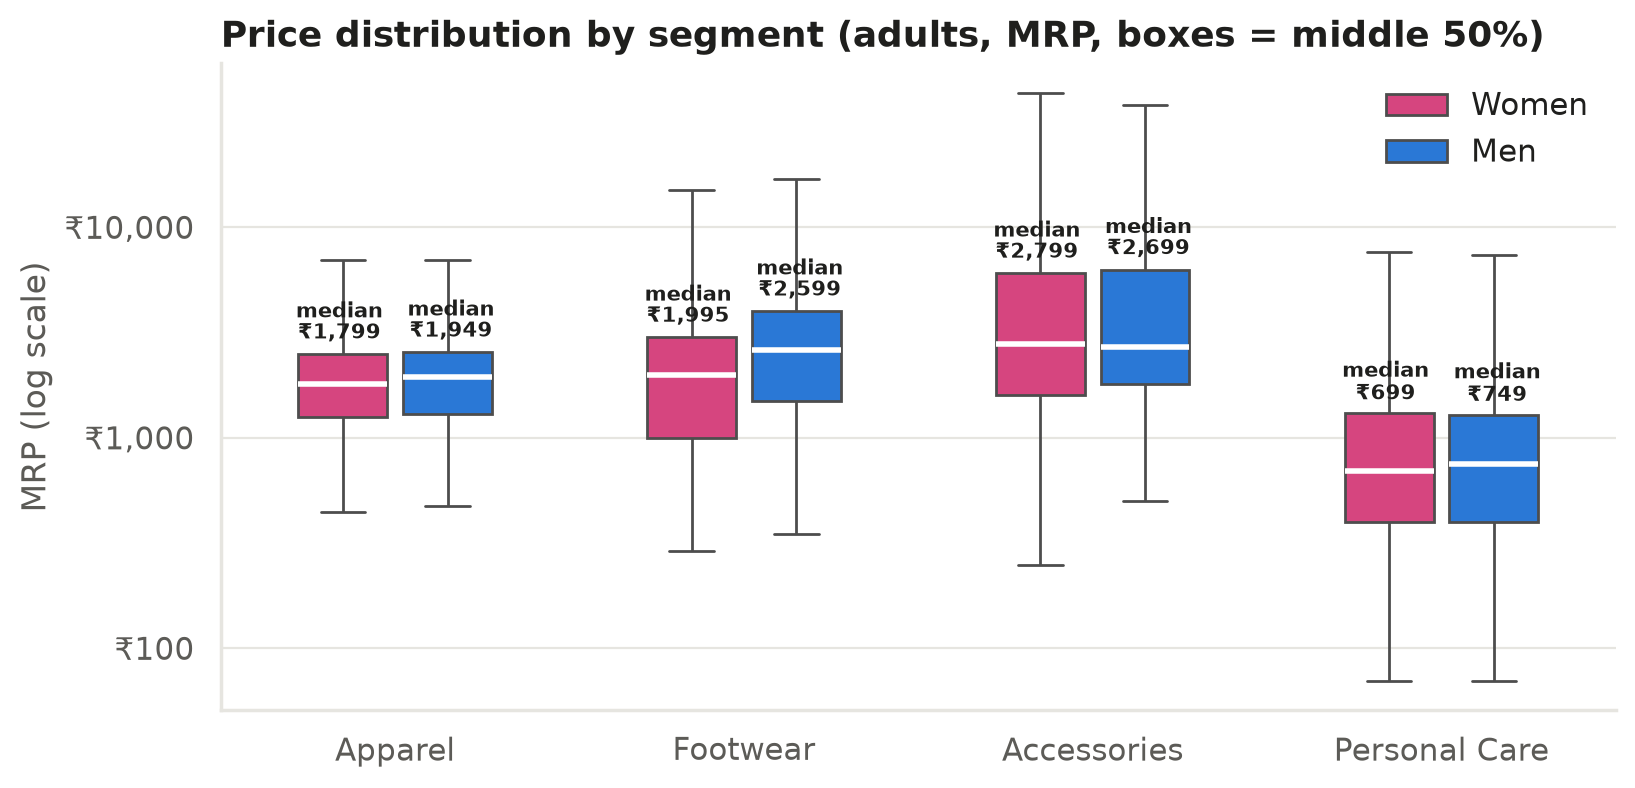

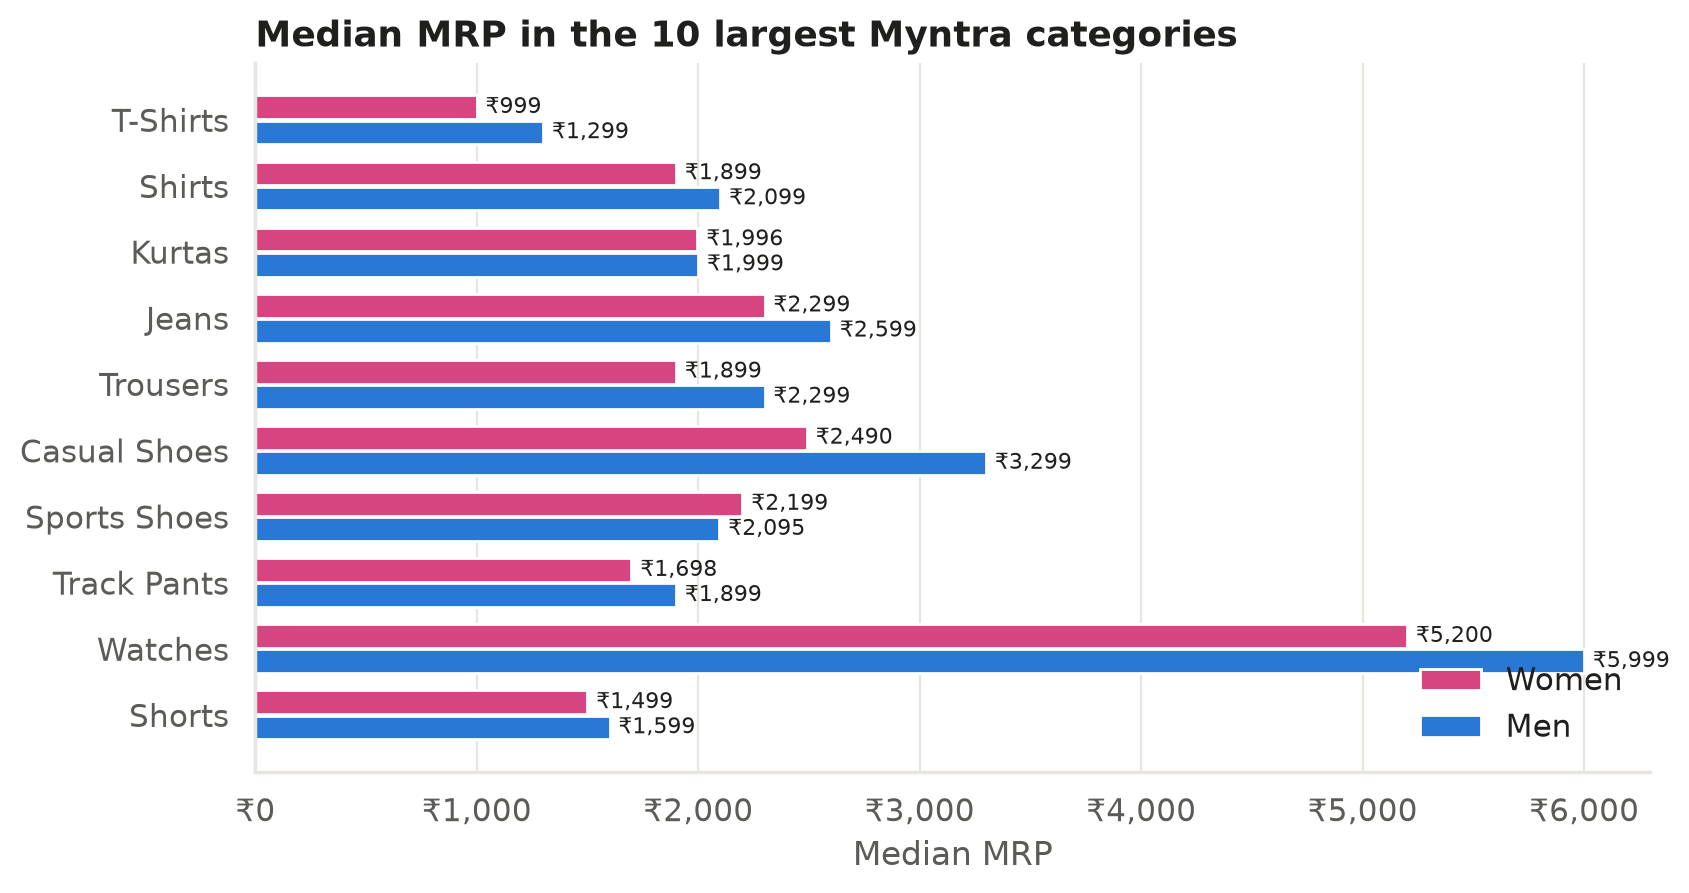

In [15]:
for f in ["fig02_dataset_composition", "fig03_price_distribution", "fig14_top_categories"]:
    display(Image(FIGURES / f"{f}.png", width=820))

## 5. Hypothesis testing
For each category: **H₀** — women's and men's prices come from the same distribution;
**H₁** — they differ.

* Mann-Whitney U test (no normality assumption)
* Welch's t-test on log price (unequal variances)
* Cohen's *d* effect size
* Bootstrap 95 % confidence interval for the median premium (2,000 resamples)
* Benjamini-Hochberg correction because 44 categories are tested at once

Worked example — adult T-shirts on Myntra:

In [16]:
t = df[(df.source == "Myntra") & (df.category == "T-Shirts") & (df.age_group == "Adult")]
w, m = t.loc[t.gender == "Women", "mrp"], t.loc[t.gender == "Men", "mrp"]
print(f"Median  women ₹{w.median():,.0f}  vs  men ₹{m.median():,.0f}  -> premium {w.median()/m.median()-1:+.1%}")
print("Mann-Whitney U :", stats.mannwhitneyu(w, m))
print("Welch t (log)  :", stats.ttest_ind(np.log(w), np.log(m), equal_var=False))

Median  women ₹999  vs  men ₹1,299  -> premium -23.1%
Mann-Whitney U : MannwhitneyuResult(statistic=np.float64(13222124.5), pvalue=np.float64(1.0706045691935139e-115))
Welch t (log)  : TtestResult(statistic=np.float64(-23.782202786154254), pvalue=np.float64(1.823877271908368e-120), df=np.float64(7280.885115328113))


In [17]:
import json
print(json.dumps(json.load(open(TABLES / "kpis.json")), indent=2))

{
  "products": 79390,
  "categories": 44,
  "brands": 2769,
  "sources": [
    "Amazon.in",
    "BigBasket",
    "Myntra"
  ],
  "cells_tested": 44,
  "cells_women_more": 4,
  "cells_men_more": 22,
  "cells_no_gap": 18,
  "median_cell_premium_pct": -11.050466483415615,
  "matched_pairs": 860,
  "pairs_women_dearer_pct": 27.209302325581397,
  "pairs_men_dearer_pct": 54.418604651162795,
  "pairs_geo_premium_pct": -5.899389042863978,
  "fe_within_category_pct": -11.94546586963028,
  "fe_within_brand_pct": -7.7023396141259415,
  "discount_mean_women": 36.66634056410042,
  "discount_mean_men": 32.90541660479201,
  "discount_p": 5.82010066892094e-129,
  "chi2_segment_outcome": {
    "chi2": 37.03100243279607,
    "dof": 6,
    "p": 1.7365537755505614e-06
  }
}


In [18]:
cat = pd.read_csv(TABLES / "category_premium_mrp.csv")
cat[["source", "age_group", "category", "n_men", "n_women", "median_men", "median_women",
     "premium_median_pct", "ci_low_pct", "ci_high_pct", "p_adj_bh", "direction"]].round(2)

,source,age_group,category,n_men,n_women,median_men,median_women,premium_median_pct,ci_low_pct,ci_high_pct,p_adj_bh,direction
0,Myntra,Kids,Night Suits,122,174,899.0,1599.0,77.86,36.70,94.55,0.00,Women pay more
1,Myntra,Adult,Innerwear (Briefs),408,488,496.5,662.0,33.33,24.13,45.10,0.00,Women pay more
2,Amazon.in,Adult,Face Wash,95,31,360.0,450.0,25.00,0.00,42.98,0.13,No significant gap
3,Myntra,Adult,Perfume,327,178,1499.0,1798.0,19.95,-3.57,55.56,0.19,No significant gap
4,Myntra,Kids,Casual Shoes,121,119,1099.0,1299.0,18.20,-9.10,54.60,0.15,No significant gap
5,Amazon.in,Adult,Body Wash,97,28,449.0,499.0,11.14,-0.27,41.72,0.06,No significant gap
6,Myntra,Kids,Clothing Sets,216,291,1349.0,1499.0,11.12,4.90,30.47,0.00,Women pay more
7,Myntra,Adult,Sweaters,174,283,2299.0,2499.0,8.70,0.00,16.31,0.87,No significant gap
8,BigBasket,Adult,Deodorant,329,171,279.0,299.0,7.17,0.00,34.45,0.06,No significant gap
9,Myntra,Adult,Wallets,507,735,1699.0,1799.0,5.89,-3.37,12.51,0.49,No significant gap


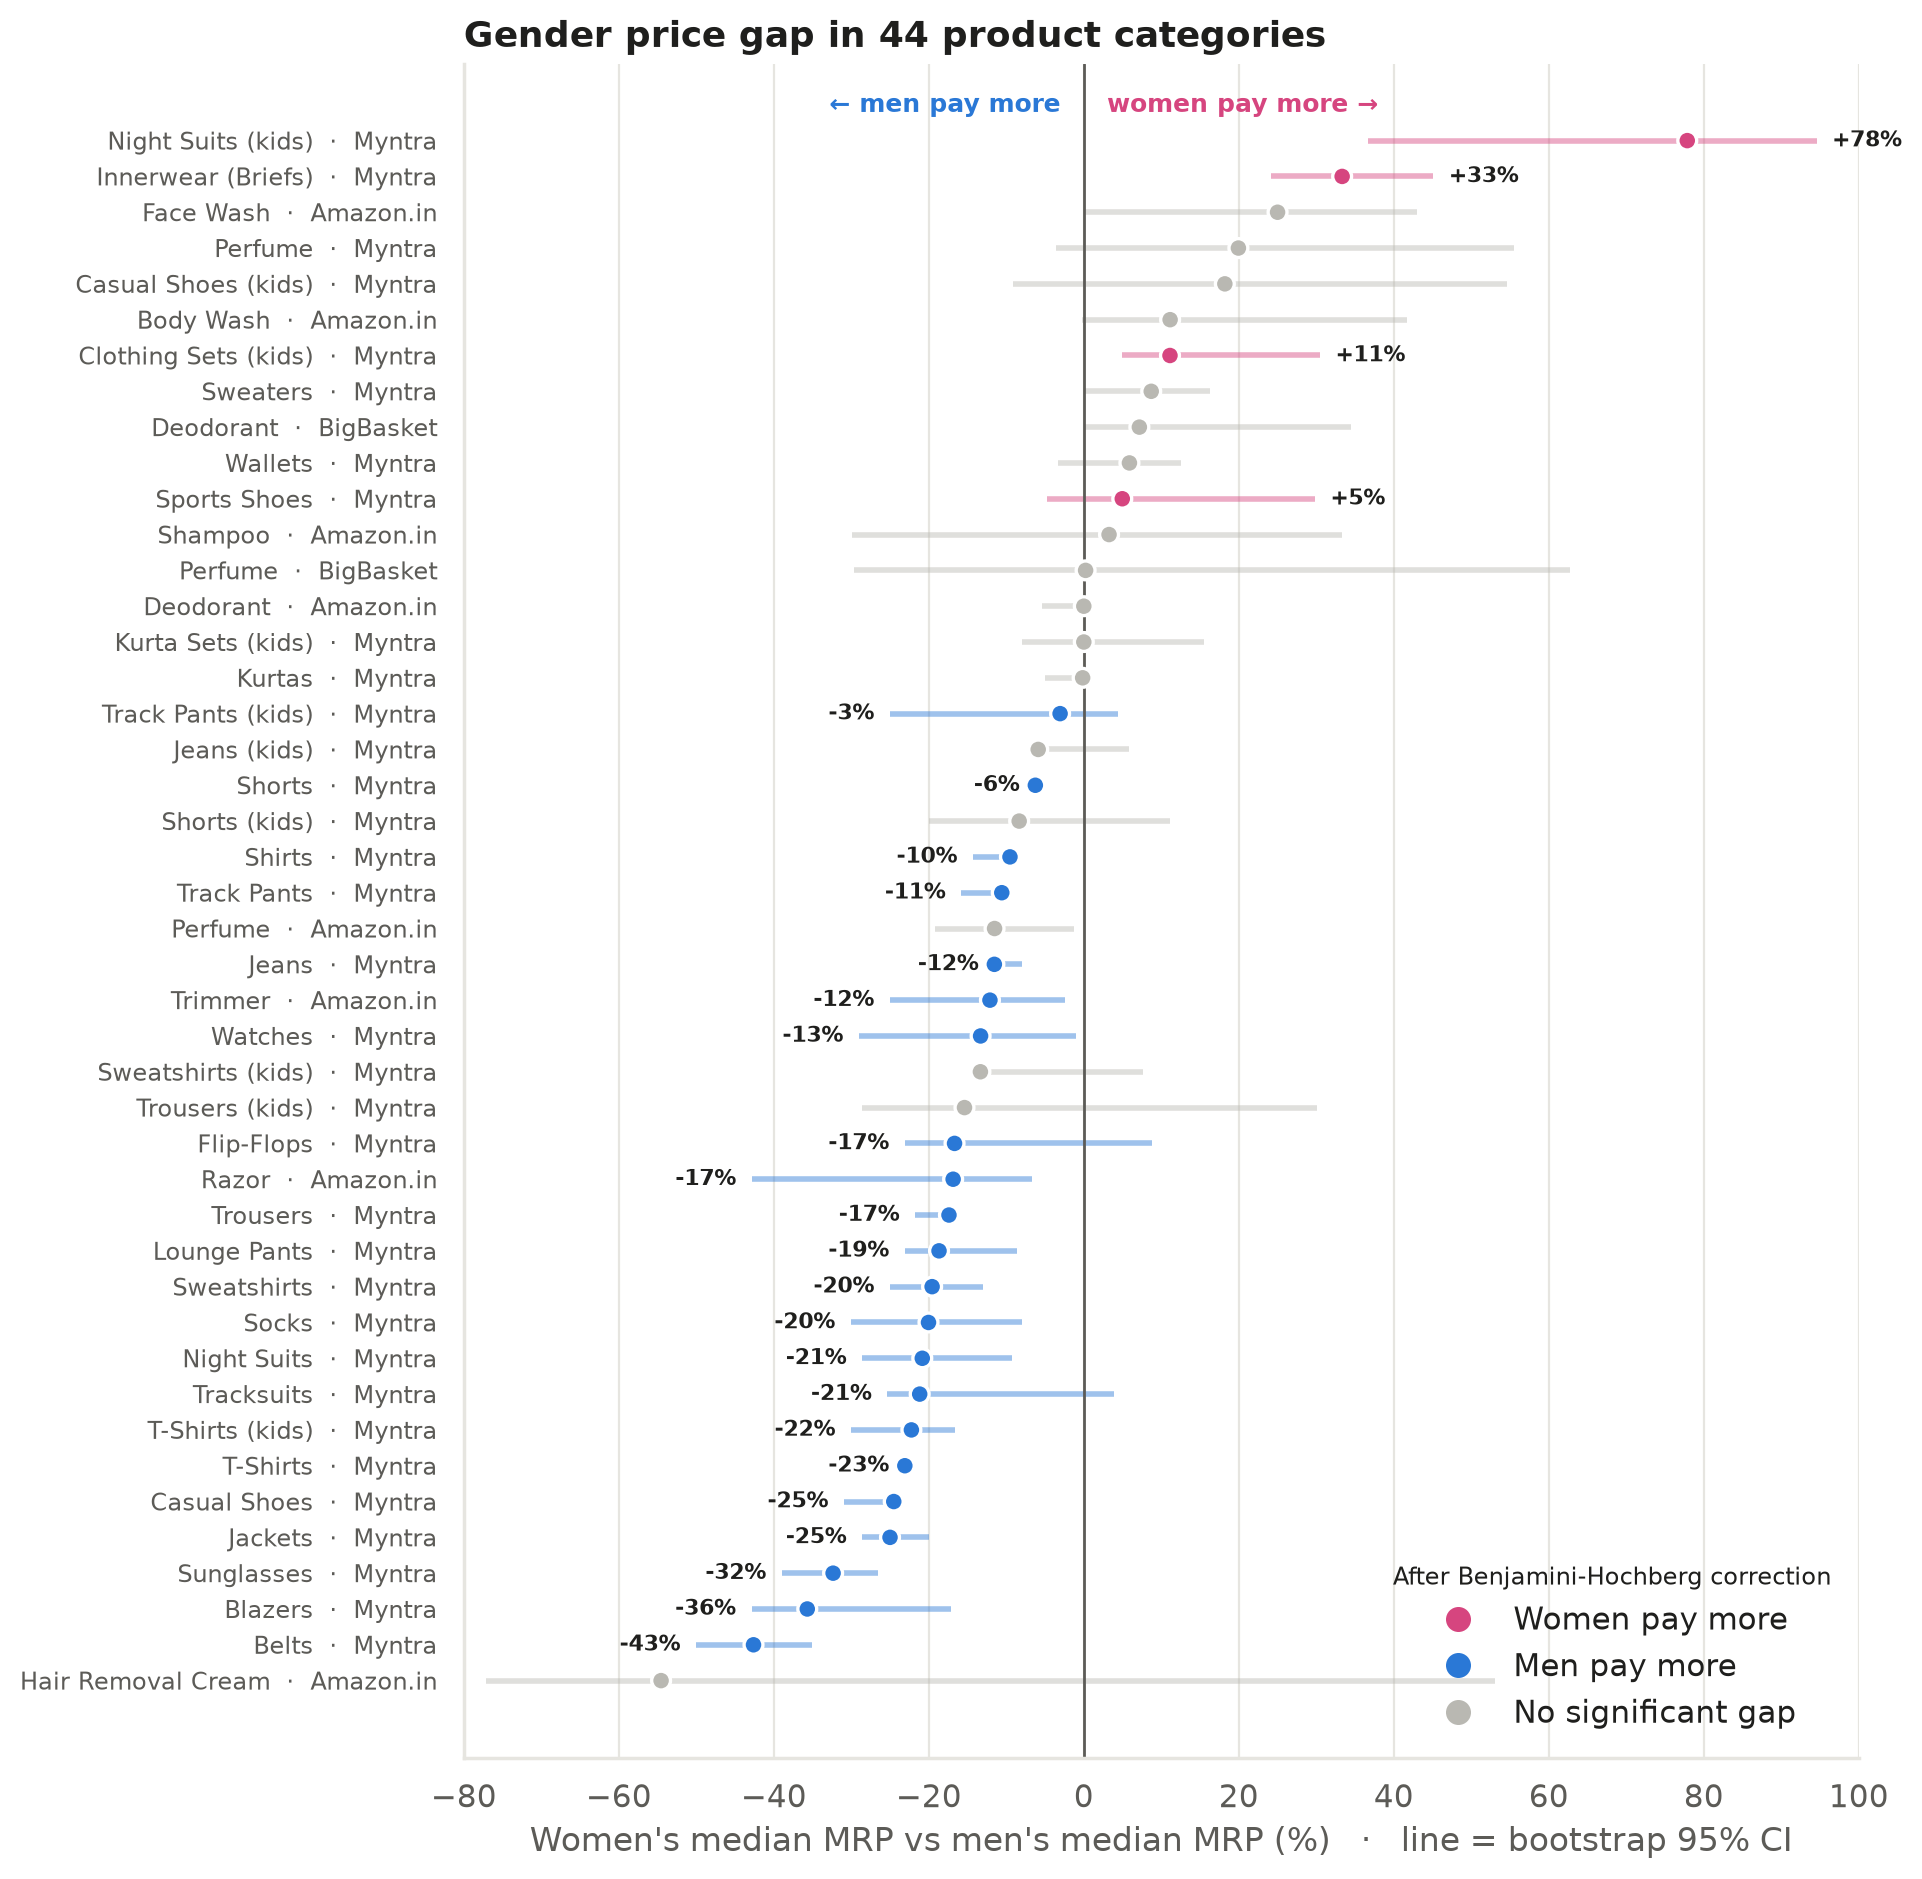

In [19]:
display(Image(FIGURES / 'fig04_category_premium.png', width=760))

In [20]:
cat.direction.value_counts()

direction
Men pay more          22
No significant gap    18
Women pay more         4
Name: count, dtype: int64

### Like-for-like: price per 100 ml

In [21]:
pd.read_csv(TABLES / "unit_price_premium.csv")[["category", "n_men", "n_women", "median_men",
    "median_women", "premium_median_pct", "p_adj_bh", "direction"]].round(2)

,category,n_men,n_women,median_men,median_women,premium_median_pct,p_adj_bh,direction
0,Deodorant,674,339,200.82,210.00,4.57,0.80,No significant gap
1,Body Wash,78,25,152.77,159.20,4.21,0.54,No significant gap
2,Perfume,2019,1137,1598.00,1530.00,-4.26,0.23,No significant gap
3,Face Wash,61,14,333.33,315.17,-5.45,0.54,No significant gap
4,Shampoo,47,20,233.00,161.00,-30.90,0.10,No significant gap


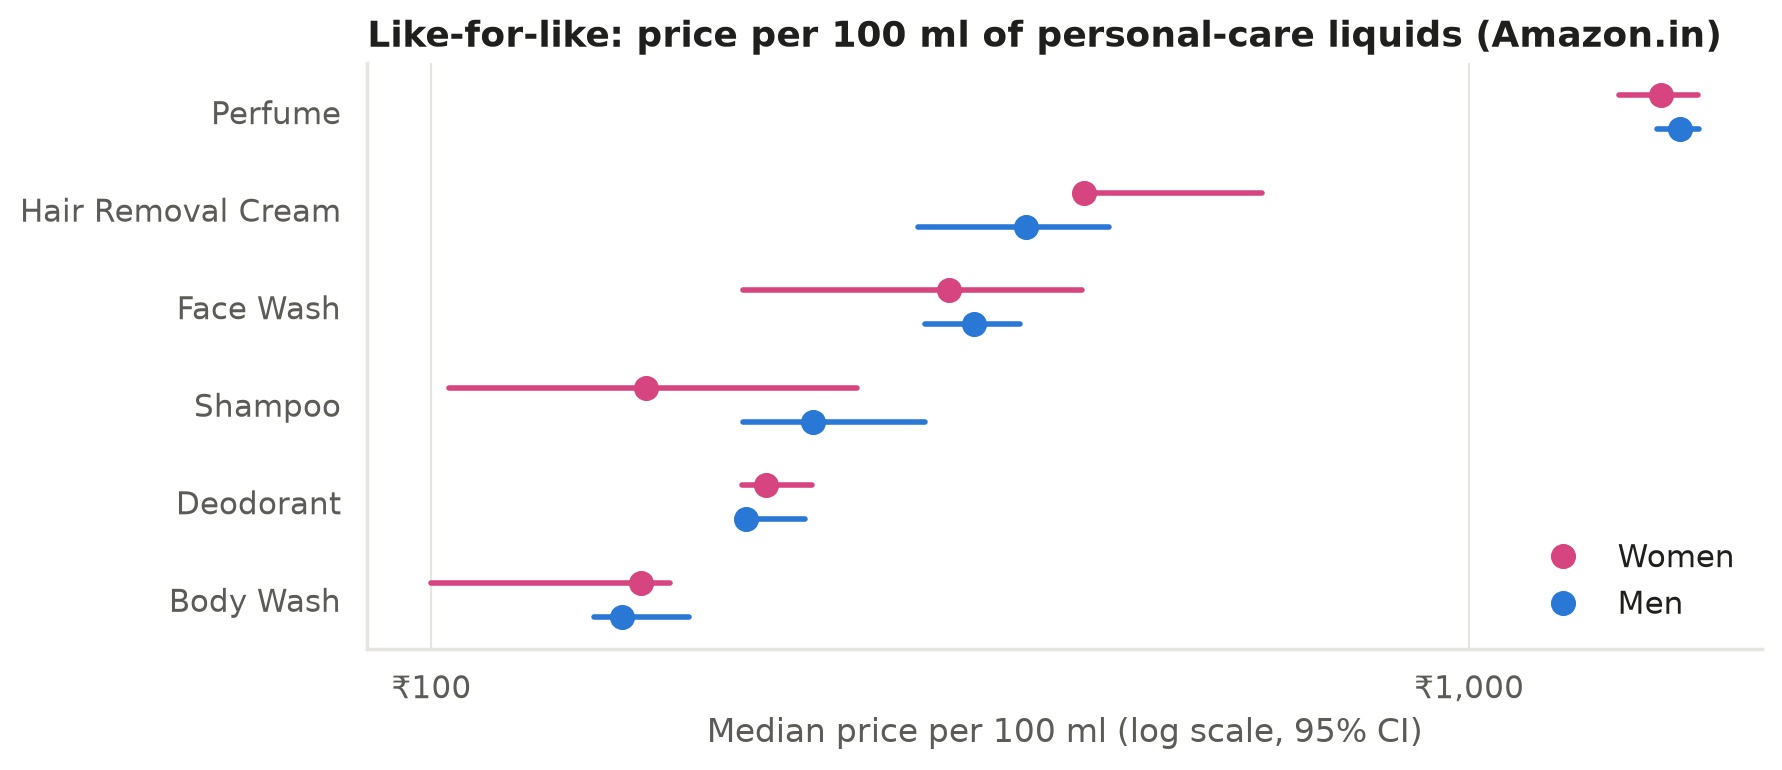

In [22]:
display(Image(FIGURES / 'fig05_unit_price.png', width=820))

## 6. Brand-matched comparison
The fairest test: take a brand that sells **both** a men's and a women's line in the same category
and compare the two medians. Wilcoxon signed-rank and sign tests check whether the gaps lean one way.

In [23]:
pd.read_csv(TABLES / 'brand_matched_summary.csv').round(3)

,scope,pairs,women_dearer_pct,men_dearer_pct,within_2pct_pct,geo_mean_premium_pct,ci_low_pct,ci_high_pct,median_premium_pct,p_wilcoxon,p_sign_test
0,All matched pairs,860,27.209,54.419,18.372,-5.899,-7.682,-3.990,-5.005,0.000,0.000
1,Segment: Accessories,54,27.778,55.556,16.667,-6.956,-13.691,0.084,-5.882,0.044,0.036
2,Segment: Apparel,475,23.579,60.421,16.000,-7.812,-9.680,-5.875,-7.144,0.000,0.000
3,Segment: Footwear,137,29.197,58.394,12.409,-7.893,-12.327,-2.797,-7.704,0.000,0.000
4,Segment: Personal Care,194,34.536,36.598,28.866,0.777,-4.028,6.187,0.000,0.929,0.799
5,Age group: Adult,739,26.793,55.210,17.997,-6.061,-8.124,-4.039,-5.266,0.000,0.000
6,Age group: Kids,121,29.752,49.587,20.661,-4.904,-9.078,-0.110,0.000,0.011,0.018


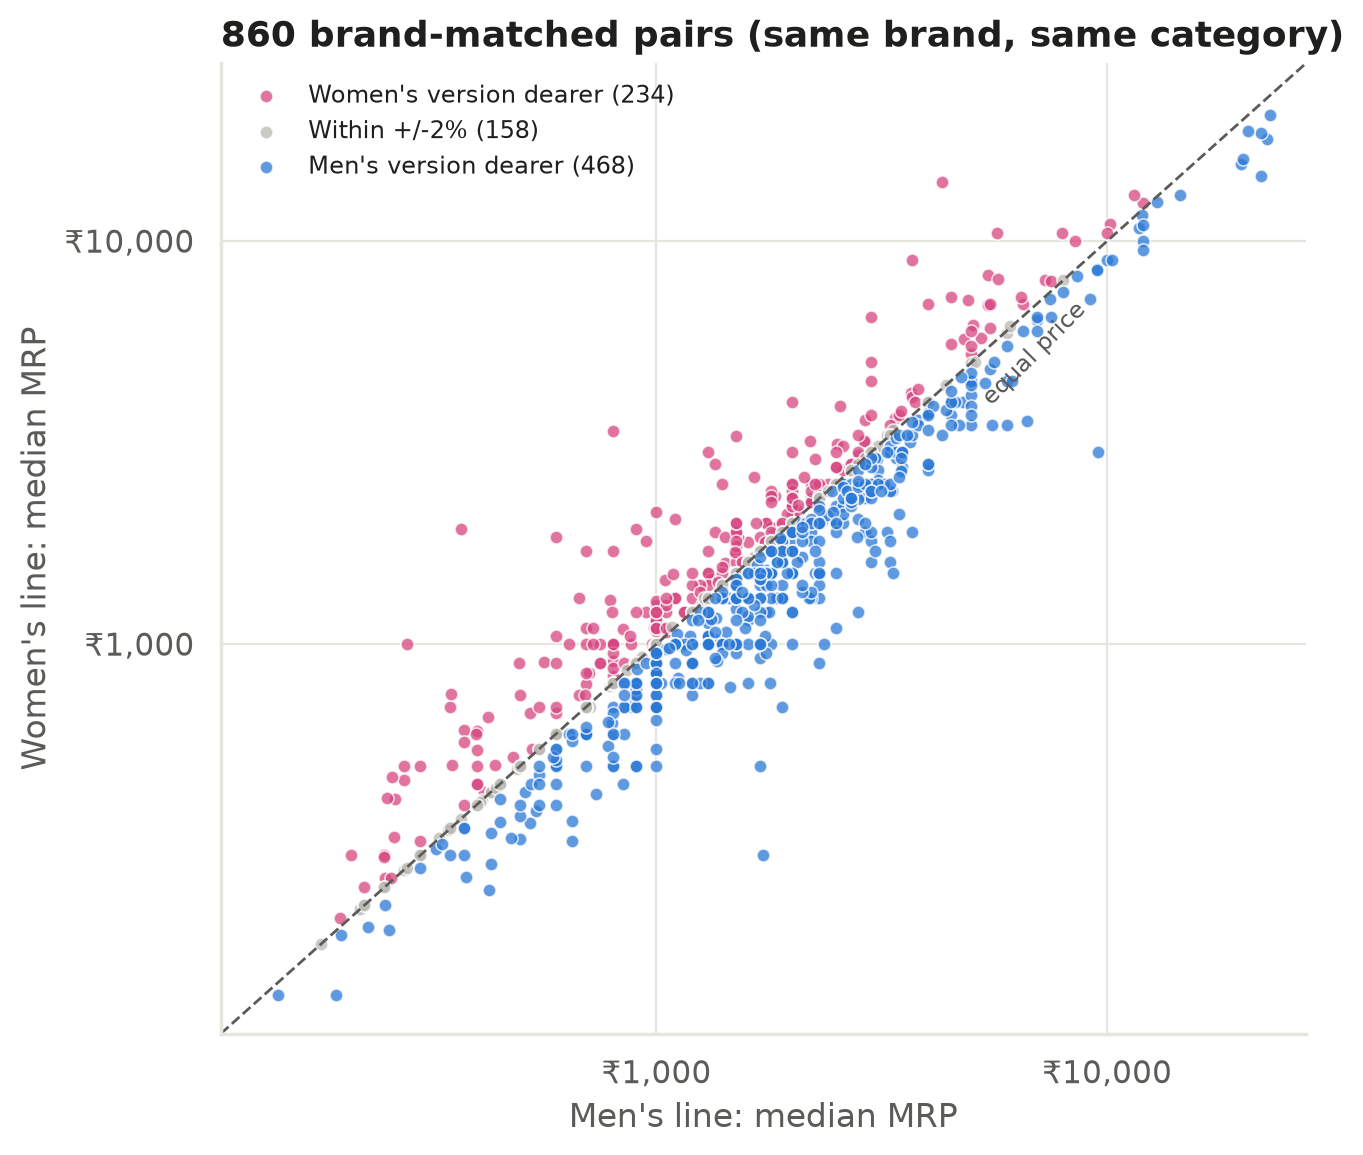

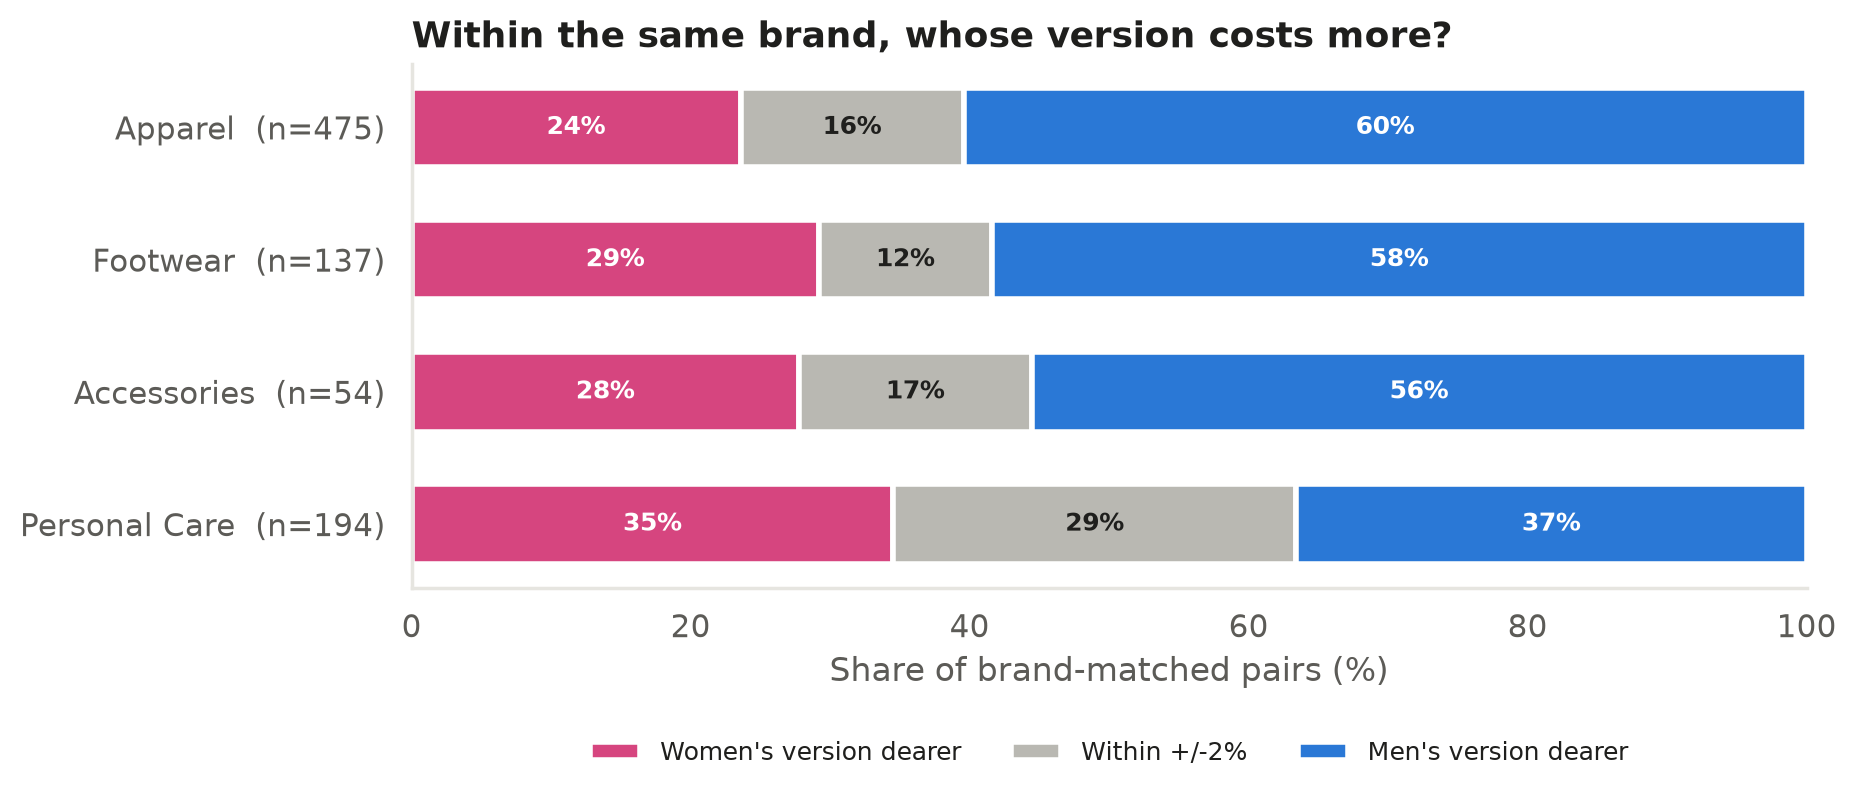

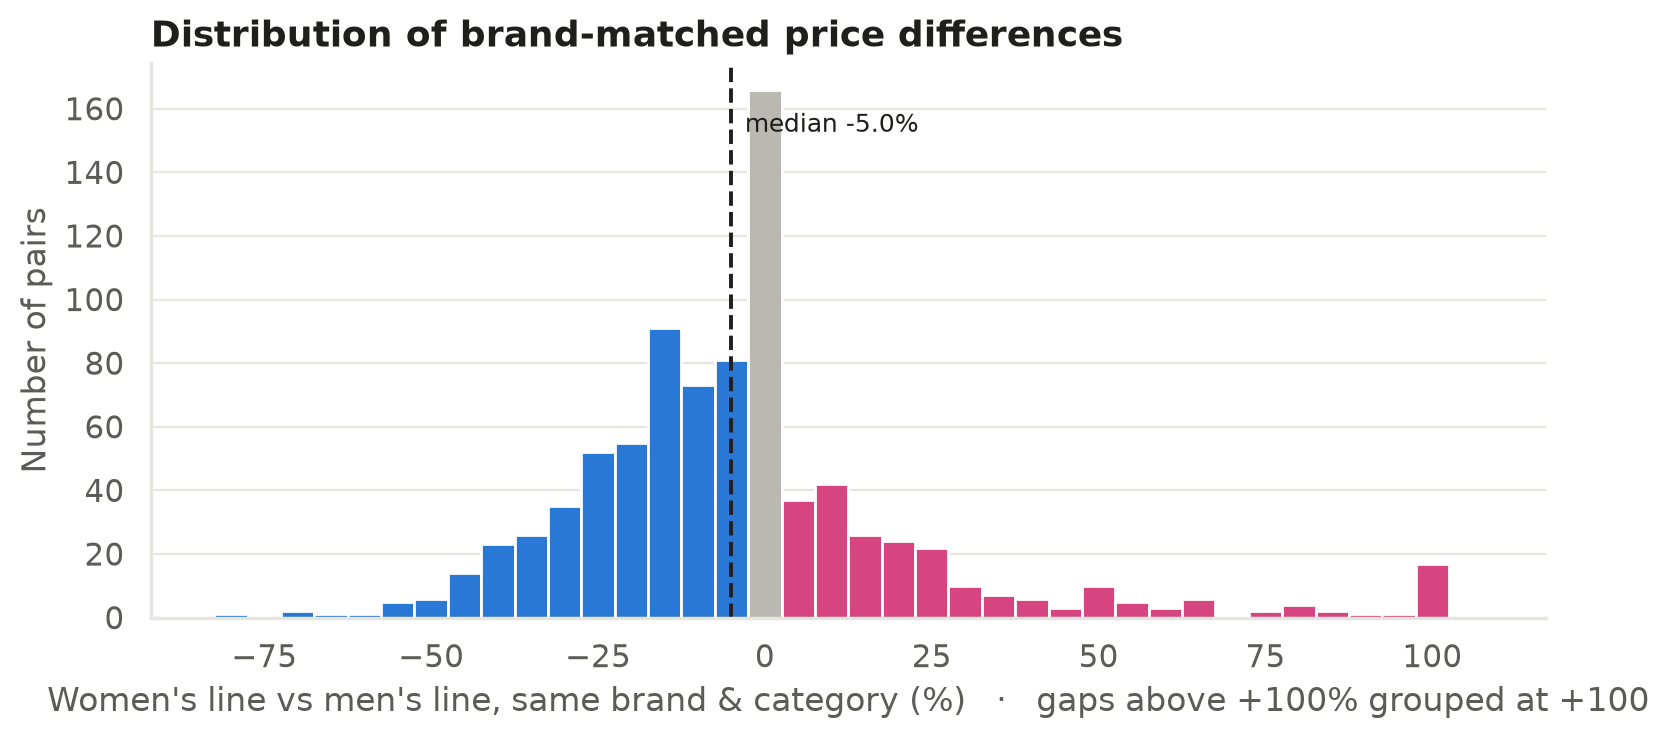

In [24]:
for f in ["fig06_brand_pairs_scatter", "fig07_pairs_outcome", "fig13_pairs_histogram"]:
    display(Image(FIGURES / f"{f}.png", width=760))

## 7. Regression with fixed effects
`log(MRP) = β·Female + (brand × category effect) + ε` — β is the average % gap between a brand's
women's and men's items in the same category. Standard errors are clustered by brand.
Below is the simpler version with category dummies, fitted with the statsmodels formula API:

In [25]:
adults = df[(df.age_group == "Adult") & (df.source == "Myntra")].assign(log_mrp=lambda d: np.log(d.mrp))
ols = smf.ols("log_mrp ~ female + C(category)", data=adults).fit(cov_type="HC1")
print(f"R-squared: {ols.rsquared:.3f}   |   observations: {int(ols.nobs):,}")
display(ols.summary2().tables[1].loc[["Intercept", "female"]].round(4))
print(f"\nWomen's premium within category: {np.exp(ols.params['female'])-1:+.1%}")

R-squared: 0.426   |   observations: 68,309


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,7.4624,0.0154,485.5887,0.0,7.4323,7.4925
female,-0.1399,0.0045,-31.3460,0.0,-0.1486,-0.1311



Women's premium within category: -13.1%


In [26]:
pd.read_csv(TABLES / 'regression_fixed_effects.csv').round(4)

,model,n_products,n_groups,n_brands,coef_female,se_cluster,premium_pct,ci_low_pct,ci_high_pct,p_value
0,Adults: within category,74669,34,2591,-0.1272,0.0297,-11.9455,-16.9264,-6.6659,0.0000
1,Adults: within brand x category,34801,1065,560,-0.0802,0.0115,-7.7023,-9.7550,-5.6030,0.0000
2,Apparel: within brand x category,22210,480,172,-0.0899,0.0161,-8.6016,-11.4384,-5.6739,0.0000
3,Footwear: within brand x category,5397,159,108,-0.1108,0.0298,-10.4868,-15.5723,-5.0950,0.0002
4,Accessories: within brand x category,3006,80,70,0.0044,0.0492,0.4432,-8.7827,10.6022,0.9283
5,Personal Care: within brand x category,4188,346,269,-0.0604,0.0265,-5.8572,-10.6187,-0.8420,0.0226
6,Kids: within category,4462,10,260,-0.0493,0.0560,-4.8100,-14.7027,6.2301,0.3786
7,Kids: within brand x category,2948,178,87,-0.0560,0.0303,-5.4484,-10.8965,0.3328,0.0643
8,Personal care Rs/100ml: within brand x category,2934,236,195,0.0117,0.0243,1.1794,-3.5297,6.1185,0.6297


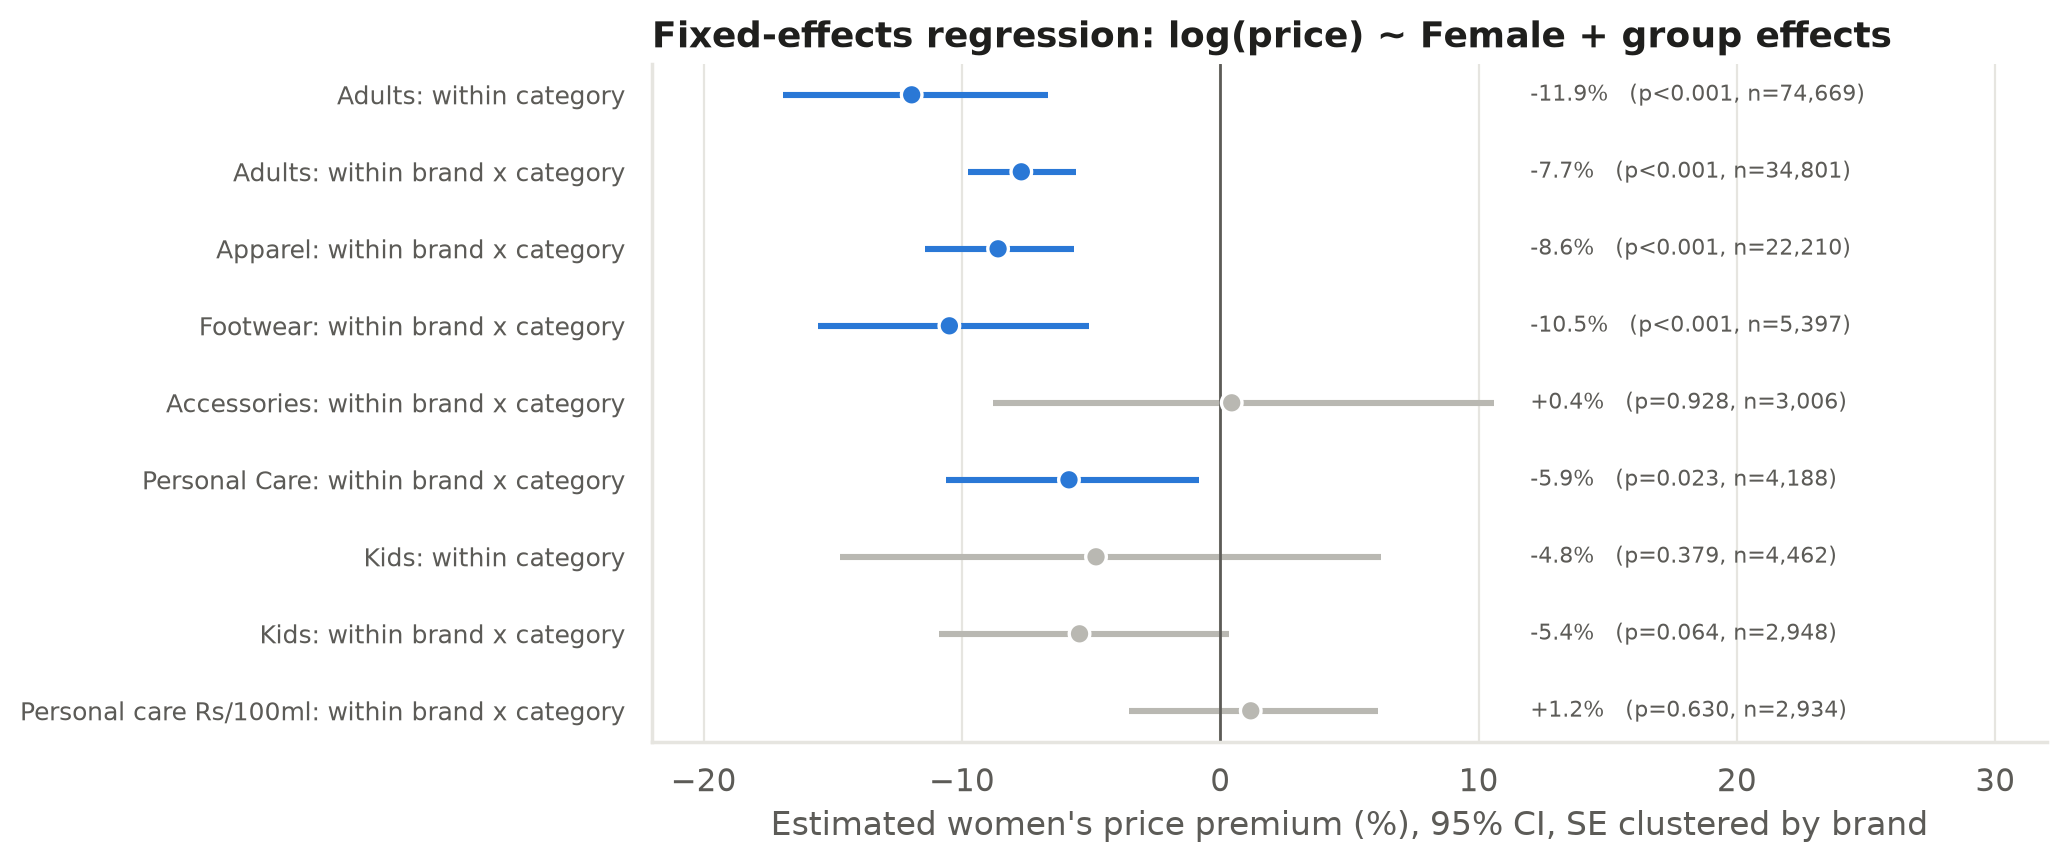

In [27]:
display(Image(FIGURES / 'fig08_regression_forest.png', width=820))

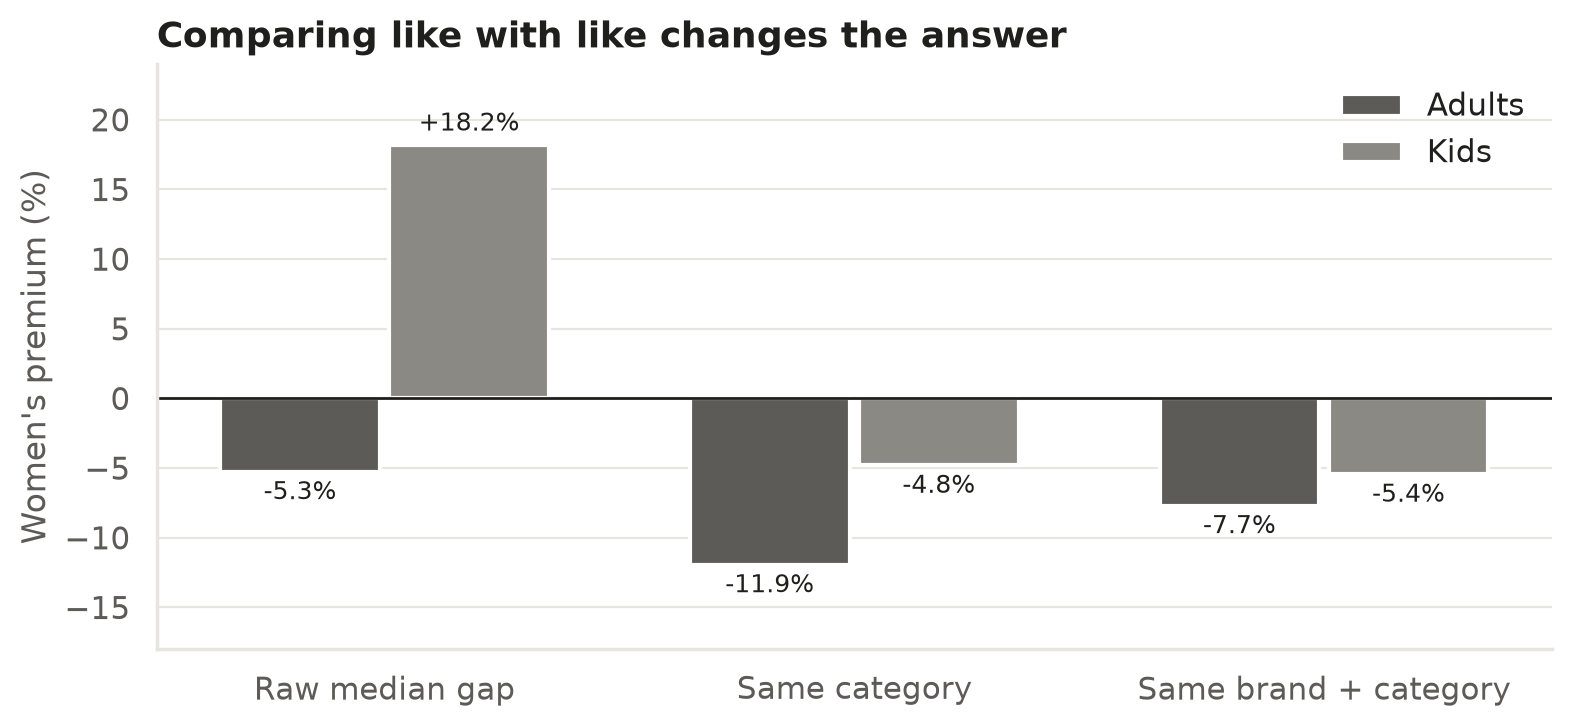

In [28]:
display(Image(FIGURES / 'fig11_composition_effect.png', width=820))

### Discounts: list price vs the price actually paid

In [29]:
pd.read_csv(TABLES / 'discount_by_gender.csv')

,segment,gender,mean,median,count
0,Accessories,Men,31.58,30.01,2290
1,Accessories,Women,37.71,40.00,2377
2,Apparel,Men,34.14,38.03,35424
3,Apparel,Women,39.00,49.97,22853
4,Footwear,Men,38.13,40.01,6410
5,Footwear,Women,34.64,40.01,2912
6,Personal Care,Men,16.67,8.03,4581
7,Personal Care,Women,17.08,9.09,2543


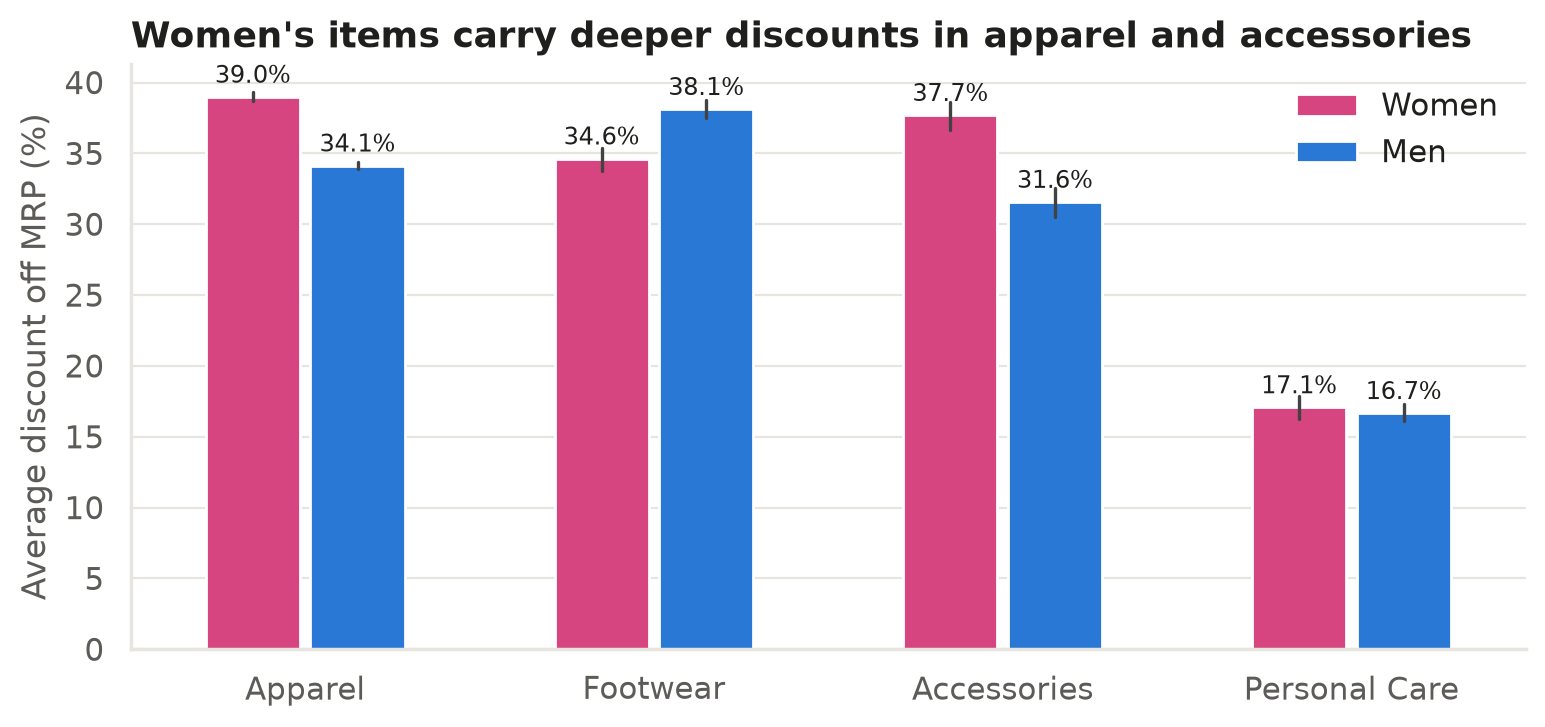

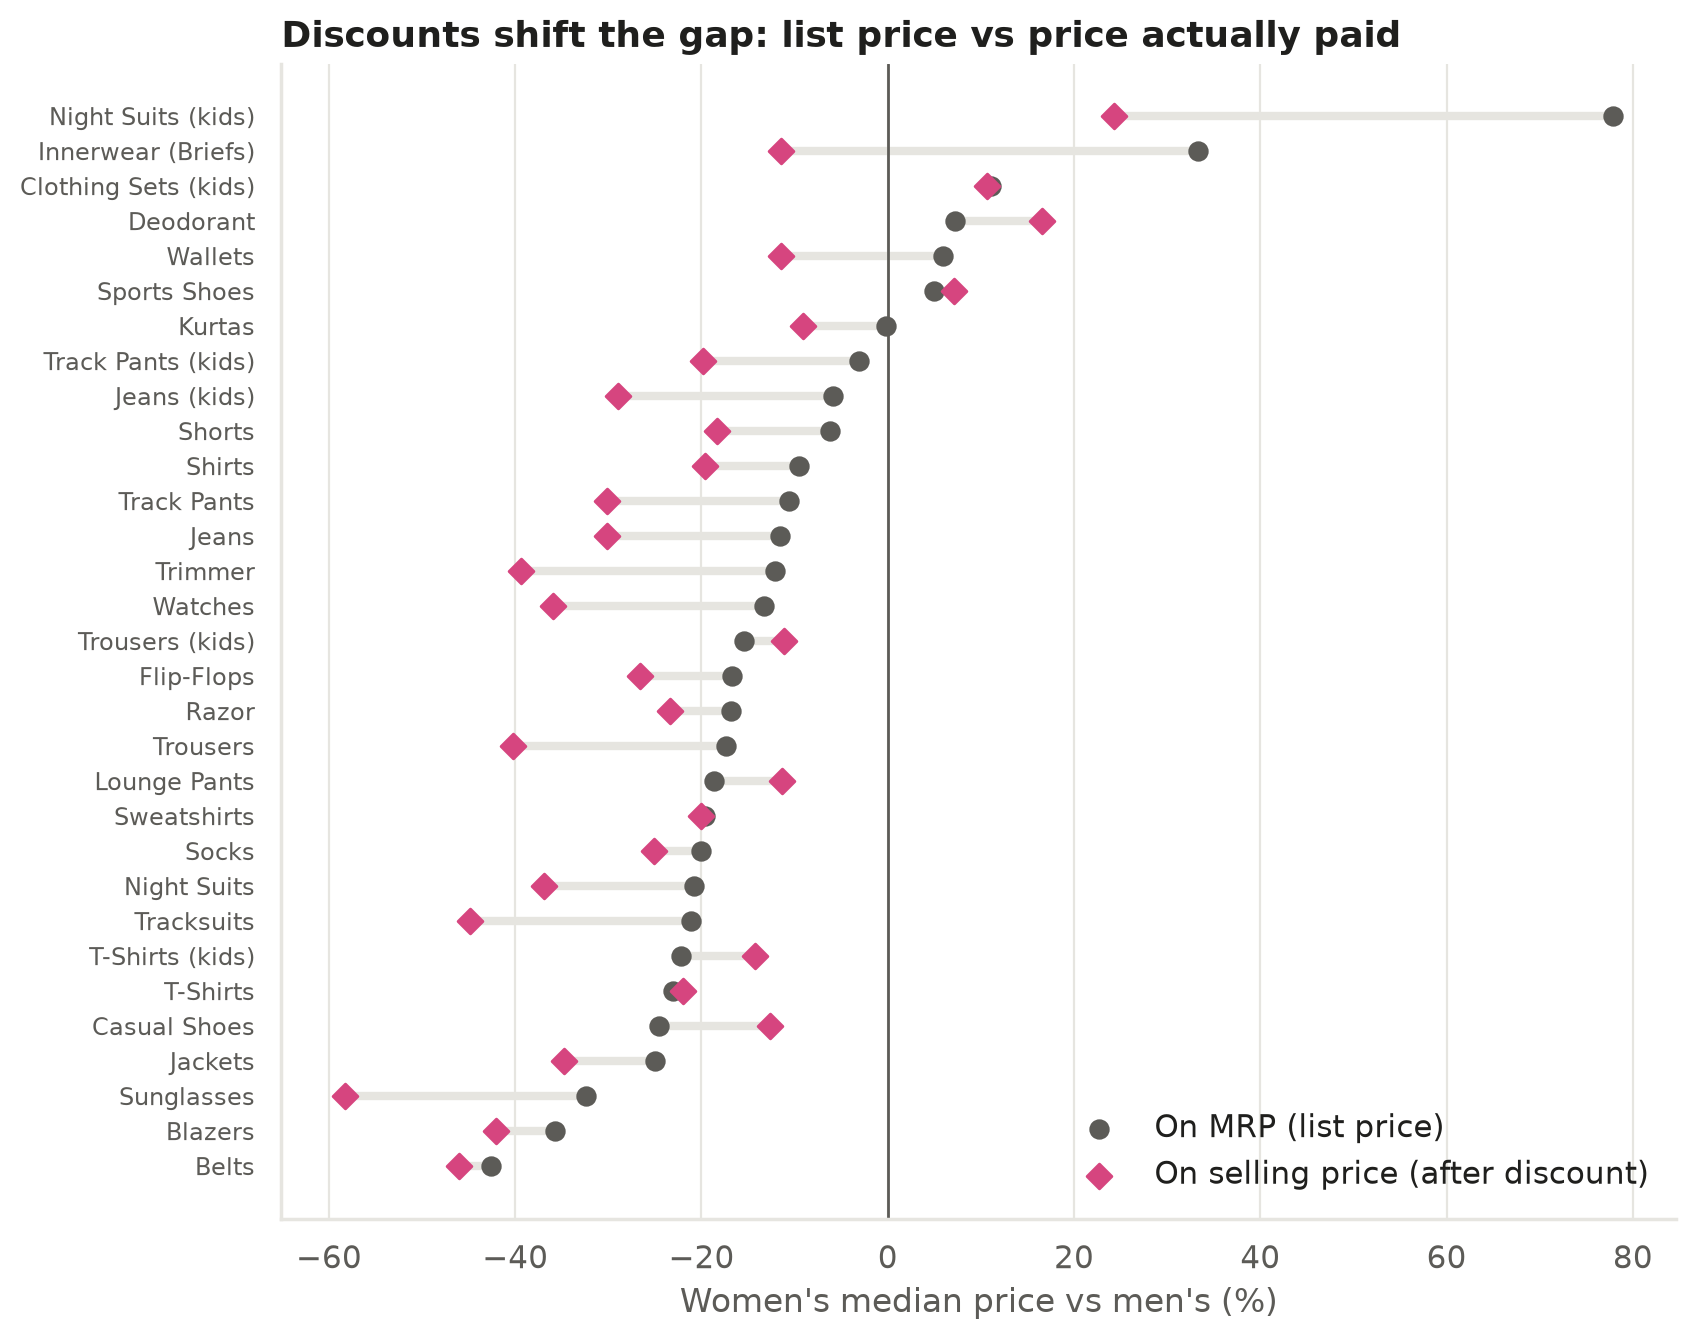

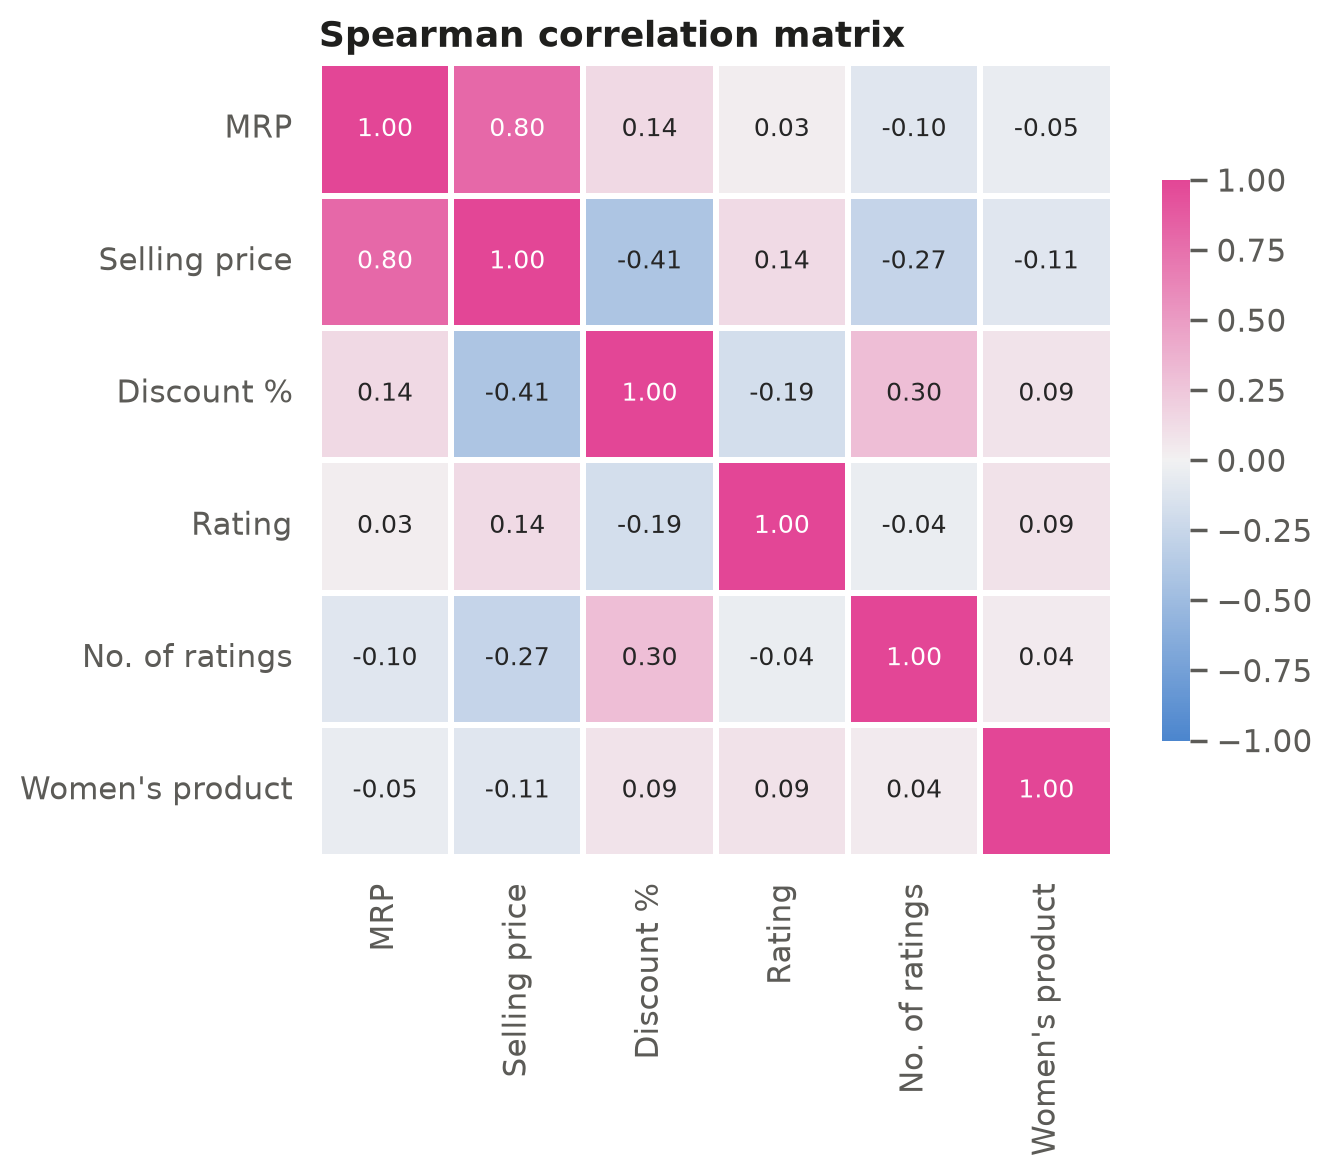

In [30]:
for f in ["fig09_discount", "fig10_mrp_vs_selling", "fig12_correlation_heatmap"]:
    display(Image(FIGURES / f"{f}.png", width=760))

## 8. Machine-learning check (scikit-learn)
A random forest predicts log price from category, segment, retailer, brand and gender.
Permutation importance shows how much each feature really matters.

In [31]:
%run ../src/06_ml_model.py

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


{'r2_test': 0.7812597319803873, 'mae_log': 0.239847059454541, 'median_abs_pct_error': 17.055461502798742}
 feature  importance      std
   brand    0.974625 0.013720
category    0.347523 0.009274
  source    0.053402 0.004414
  female    0.016197 0.001301
 segment    0.009923 0.001058
    kids    0.007808 0.001055


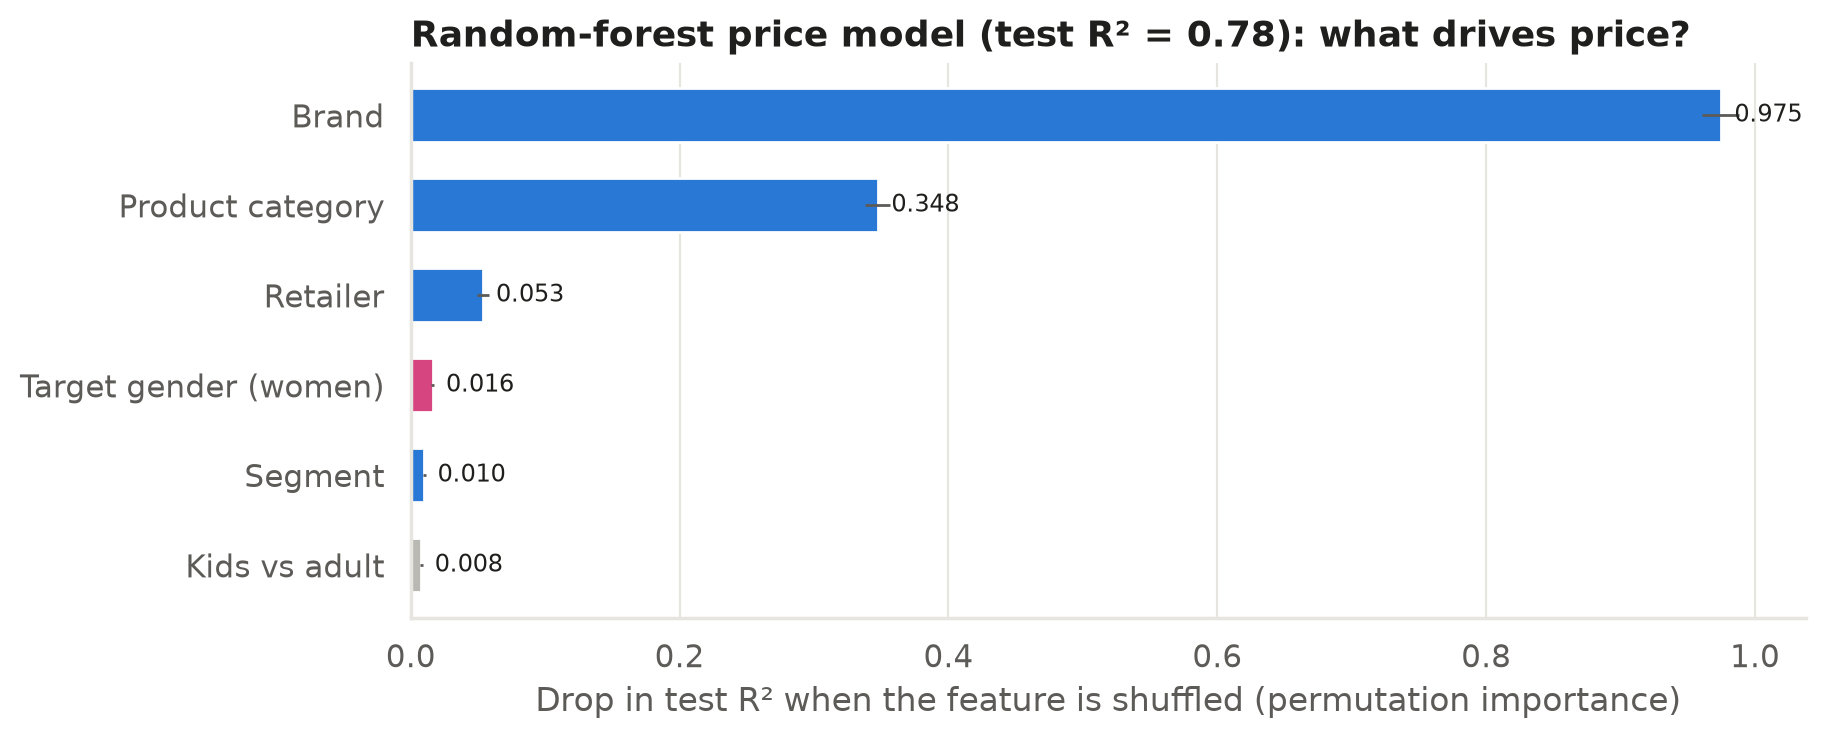

In [32]:
display(Image(FIGURES / 'fig15_ml_feature_importance.png', width=820))

## 9. Exports: interactive chart, Excel workbook and Power BI files

In [33]:
import plotly.express as px
seg = (df[df.age_group == "Adult"].groupby(["segment", "gender"]).mrp.median().reset_index())
fig = px.bar(seg, x="segment", y="mrp", color="gender", barmode="group",
             color_discrete_map=GENDER_COLORS, text_auto=".0f",
             labels={"mrp": "Median MRP (₹)", "segment": ""}, title="Median MRP by segment")
fig.update_layout(template="plotly_white")
fig.show()

In [34]:
%run ../src/05_build_excel.py

saved /home/user/PinkTax/excel/PinkTax_Analysis.xlsx


In [35]:
%run ../src/07_powerbi_export.py

Power BI files written to /home/user/PinkTax/powerbi


## 10. Key findings
1. **No blanket Pink Tax.** Of 44 categories, women pay significantly more in only 4
   (girls' night suits, innerwear, kids' clothing sets, sports shoes); men pay more in 22.
2. **Same brand, same category:** the women's line is dearer in 27 % of 860 pairs and the men's line
   in 54 %; the typical gap is about −6 % (women pay less).
3. **Personal care per 100 ml:** no significant gap (+1.2 %, p = 0.63) once brand and pack size are
   controlled for.
4. **Pockets of Pink Tax** remain — innerwear (+33 % on MRP), girls' nightwear (+78 %), some perfumes
   and wallets (the innerwear gap disappears within the same brand, so it is a brand-mix effect) — and they are what consumers notice.
5. **Discounts matter:** women's items carry deeper discounts (36.7 % vs 32.9 %), so the price paid
   often differs from the list price.
6. **Brand and category explain price; gender barely does** (ML permutation importance 0.02 vs 0.97).